# Fused CV benchmarks

Compare fused CV with in-core CV on one GPU.
In-core CV uses **fold-local cuts**; fused CV uses full-data cuts, so RMSE can differ.
Both methods use identical folds and return host OOF predictions after a fixed number
of rounds. Data generation is excluded; construction, training, and prediction are timed.

Edit the settings below and run all cells with this branch's CUDA-enabled XGBoost.
Increase the dataset sizes for external-memory workloads; the in-core baseline needs
one fold's training/validation matrices and training state to fit on the GPU.

In [1]:
import gc
from concurrent.futures import ThreadPoolExecutor
from contextlib import contextmanager
from time import perf_counter

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import _cross_validation as xcv

ROW_COUNTS = [2**26]
N_FEATURES = 1024
K_FOLDS = 5
N_ROUNDS = 32
BATCH_ROWS = 2**19
SEED = 2026
CACHE_HOST_RATIO = 1.0  # Keep the fused CV cache on the host.
TREE_PARAMS = {
    "max_depth": 6,
    "max_bin": 256,
    "learning_rate": 0.1,
}

gpu_pool = cp.cuda.MemoryAsyncPool(pool_handles="default")
cp.cuda.set_allocator(gpu_pool.malloc)
xgb.set_config(use_cuda_async_pool=True, verbosity=0)
BASELINE_PARAMS = {
    **TREE_PARAMS,
    "device": f"cuda",
    "tree_method": "hist",
    "objective": "reg:squarederror",
    "base_score": 0.5,
    "boost_from_average": 0,
    "multi_strategy": "multi_output_tree",
}
METHODS = ["Fused CV", "In-core CV"]

The iterator stages one batch at a time and preserves row order. Training matrices
for in-core CV compute their own cuts; validation matrices use `ref=train`.
Replace `make_data` with your own host-array loader if needed.

`make_data` fills independent row chunks in parallel. Each chunk has its own seeded
random stream, so thread scheduling and `n_threads` do not affect the generated data.

In [2]:
def make_data(n_rows, n_features, seed, *, n_threads=None):
    """Generate independent row chunks, reproducibly across thread counts."""
    X = np.empty((n_rows, n_features), dtype=np.float32)
    y = np.empty(n_rows, dtype=np.float32)
    chunk_rows = 2**16
    n_chunks = (n_rows + chunk_rows - 1) // chunk_rows
    seeds = np.random.SeedSequence(seed).spawn(n_chunks)

    def fill_chunk(i):
        begin = i * chunk_rows
        end = min(begin + chunk_rows, n_rows)
        rng = np.random.default_rng(seeds[i])
        batch = X[begin:end]
        rng.standard_normal(batch.shape, dtype=np.float32, out=batch)
        y[begin:end] = (
            2.0 * batch[:, 0]
            + 0.5 * batch[:, 1] ** 2
            + np.sin(batch[:, 2])
            + (batch[:, 0] > 0) * batch[:, 3]
            + 0.1 * rng.standard_normal(end - begin, dtype=np.float32)
        )

    with ThreadPoolExecutor(max_workers=n_threads) as executor:
        list(executor.map(fill_chunk, range(n_chunks)))
    return X, y


def make_fold_ids(n_rows):
    ids = np.arange(n_rows, dtype=np.int32) % K_FOLDS
    np.random.default_rng(SEED + 1).shuffle(ids)
    return ids


class HostBatchIter(xgb.DataIter):
    def __init__(self, X, y, ids, *, fold=None, validation=False):
        super().__init__(cache_prefix=None, on_host=True, release_data=True)
        self.X, self.y, self.ids = X, y, ids
        self.fold, self.validation = fold, validation
        self.position = 0

    def reset(self):
        self.position = 0

    def next(self, input_data):
        while self.position < len(self.y):
            begin = self.position
            end = min(begin + BATCH_ROWS, len(self.y))
            self.position = end
            X, y = self.X[begin:end], self.y[begin:end]
            if self.fold is not None:
                keep = self.ids[begin:end] == self.fold
                if not self.validation:
                    keep = ~keep
                if not keep.any():
                    continue
                X, y = X[keep], y[keep]
            input_data(data=cp.asarray(X), label=cp.asarray(y))
            return True
        return False


def make_matrix(X, y, ids, *, fold=None, validation=False, ref=None):
    iterator = HostBatchIter(X, y, ids, fold=fold, validation=validation)
    kwargs = {"max_bin": TREE_PARAMS["max_bin"], "ref": ref}
    if fold is None:
        return xgb.ExtMemQuantileDMatrix(
            iterator, cache_host_ratio=CACHE_HOST_RATIO, **kwargs
        )
    return xgb.QuantileDMatrix(iterator, **kwargs)

In [3]:
def stamp():
    cp.cuda.runtime.deviceSynchronize()
    return perf_counter()


@contextmanager
def timed(times, phase):
    start = stamp()
    yield
    times[phase] += stamp() - start


def release_unused():
    gc.collect()
    cp.cuda.runtime.deviceSynchronize()
    gpu_pool.free_all_blocks()

In [4]:
def run_fused(X, y, ids, rounds):
    times = dict.fromkeys(["build_s", "train_s", "predict_s"], 0.0)
    with timed(times, "build_s"):
        data = make_matrix(X, y, ids)
        assignment = xcv.FoldAssignment(ids, k_folds=K_FOLDS)
        models = xcv.FoldModels(data, K_FOLDS)
        predictions = xcv.FoldPredictions()
        models.init_prediction(data, predictions, assignment=assignment)
        gradients = xcv.FoldGpairs()
        updater = xcv.FoldTreeMethod(models, data, params=TREE_PARAMS)
    with timed(times, "train_s"):
        for iteration in range(rounds):
            models.get_gradient(data, iteration, predictions, out=gradients)
            updater.update(models, data, gradients, predictions)
    with timed(times, "predict_s"):
        oof = cp.asnumpy(predictions.get_valid(copy=False)).reshape(-1)
    return times, oof


def run_in_core(X, y, ids, rounds):
    times = dict.fromkeys(["build_s", "train_s", "predict_s"], 0.0)
    with timed(times, "build_s"):
        oof = np.full(len(y), np.nan, dtype=np.float32)
    for fold in range(K_FOLDS):
        with timed(times, "build_s"):
            train = make_matrix(X, y, ids, fold=fold)
            valid = make_matrix(X, y, ids, fold=fold, validation=True, ref=train)
            model = xgb.Booster(BASELINE_PARAMS, cache=[train, valid])
        with timed(times, "train_s"):
            for iteration in range(rounds):
                model.update(train, iteration)
        with timed(times, "predict_s"):
            oof[ids == fold] = model.predict(valid, output_margin=True).reshape(-1)
        # Release this fold before constructing the next one.
        del model, valid, train
    return times, oof


def run_once(method, X, y, ids, rounds):
    start = stamp()
    if method == "Fused CV":
        times, oof = run_fused(X, y, ids, rounds)
    else:
        times, oof = run_in_core(X, y, ids, rounds)
    times["total_s"] = stamp() - start
    times["fit_oof_s"] = times["train_s"] + times["predict_s"]
    assert oof.shape == y.shape and np.isfinite(oof).all()
    # Scoring is common to both methods and is outside the timers.
    squared_error = (oof.astype(np.float64) - y) ** 2
    fold_rmse = [float(np.sqrt(squared_error[ids == k].mean())) for k in range(K_FOLDS)]
    times["mean_fold_rmse"] = float(np.mean(fold_rmse))
    return times

Each method gets a small warm-up, then one measured CV run per dataset size.
Each run uses fresh matrices and models.
Methods run in the order listed in `METHODS`. CUDA is synchronized at timing boundaries.
Total time includes construction and cleanup; `fit_oof_s` measures training plus
prediction. Fused CV computes OOF predictions during training. RMSE is scored afterward.

In [5]:
X, y = make_data(max(2048, K_FOLDS * 8), N_FEATURES, SEED)
ids = make_fold_ids(len(y))
for method in METHODS:
    release_unused()
    run_once(method, X, y, ids, rounds=2)
del X, y, ids

records = []
benchmark_data = {}  # Retain host arrays for the refit comparison below.
for n_rows in ROW_COUNTS:
    X, y = make_data(n_rows, N_FEATURES, SEED)
    ids = make_fold_ids(n_rows)
    benchmark_data[n_rows] = (X, y, ids)
    for method in METHODS:
        release_unused()
        stats = run_once(method, X, y, ids, N_ROUNDS)
        records.append(dict(method=method, n_rows=n_rows, **stats))
        print(f"{n_rows:,} rows | {method} | {stats['total_s']:.3f}s")
    del X, y, ids
release_unused()

results = pd.DataFrame(records)
summary = results.set_index(["n_rows", "method"]).sort_index()
summary.round(4)

67,108,864 rows | Fused CV | 367.117s
67,108,864 rows | In-core CV | 582.405s


build_s   train_s  predict_s   total_s  fit_oof_s  \
n_rows   method                                                           
67108864 Fused CV     64.9345  300.2012     0.0189  367.1173   300.2201   
         In-core CV  467.2974  113.8109     1.1274  582.4052   114.9383   

                     mean_fold_rmse  
n_rows   method                      
67108864 Fused CV            0.2959  
         In-core CV          0.2963

Plots compare training time, training plus OOF prediction, total time, and validation
error for one CV run per method and dataset size. Total time includes construction
and cleanup in addition to training and prediction.

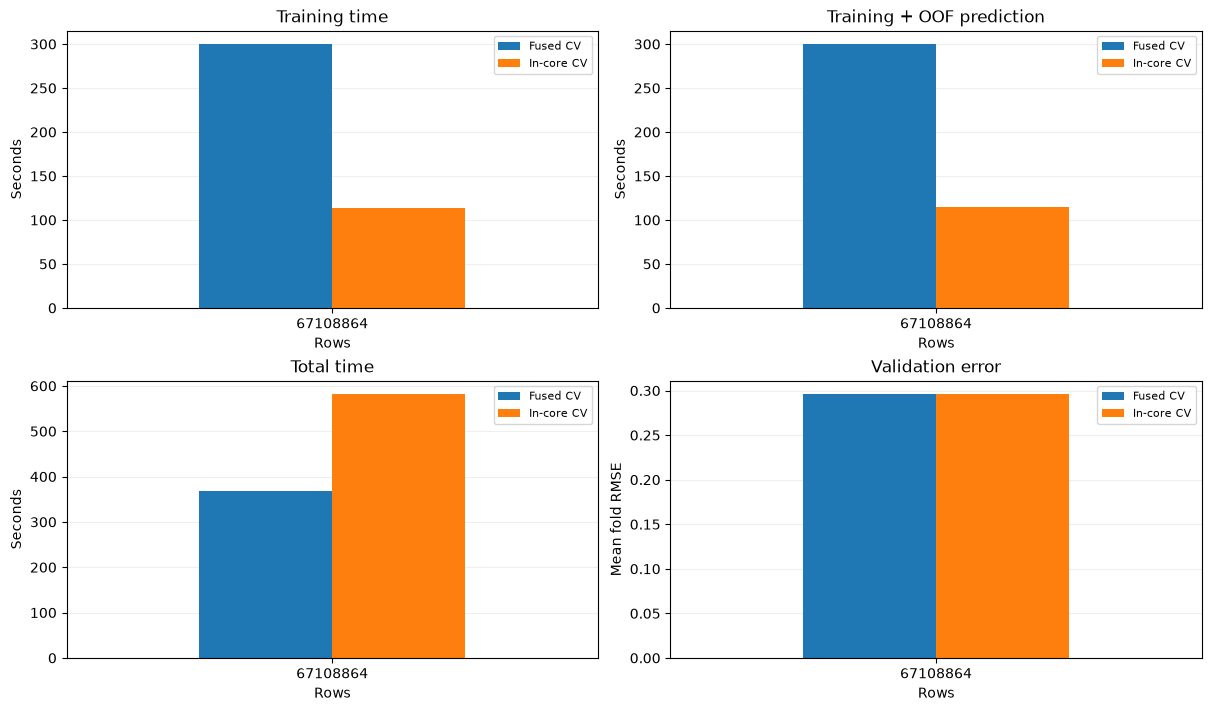

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained")
for ax, column, title, ylabel in [
    (axes[0, 0], "train_s", "Training time", "Seconds"),
    (axes[0, 1], "fit_oof_s", "Training + OOF prediction", "Seconds"),
    (axes[1, 0], "total_s", "Total time", "Seconds"),
    (axes[1, 1], "mean_fold_rmse", "Validation error", "Mean fold RMSE"),
]:
    summary[column].unstack("method").reindex(columns=METHODS).plot.bar(ax=ax, rot=0)
    ax.set(title=title, ylabel=ylabel)

for ax in axes.flat:
    ax.set_xlabel("Rows")
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=8)
plt.show()

## CV with full-data refit

Repeat the comparison with `K_FOLDS` fold models plus one model trained on all rows
for `N_ROUNDS`. Fused CV trains the refit inside its shared page loop; in-core CV
trains it after the folds. Construction and training times include the refit, while
validation RMSE still uses only the fold models' OOF predictions. The full-data
refit matrix and its training state must fit on the GPU for the in-core baseline.

This section reuses the exact features, labels, and fold IDs retained in
`benchmark_data` by the earlier benchmark. No data are copied or regenerated.
Datasets stay in host memory for this additional comparison. If the earlier
benchmark cell was executed before this section was added, rerun that cell once
to retain its arrays. The original results and plots remain separate.

In [7]:
def run_fused_refit(X, y, ids, rounds):
    times = dict.fromkeys(["build_s", "train_s", "predict_s"], 0.0)
    with timed(times, "build_s"):
        data = make_matrix(X, y, ids)
        assignment = xcv.FoldAssignment(ids, k_folds=K_FOLDS)
        models = xcv.FoldModels(data, K_FOLDS, refit=True)
        predictions = xcv.FoldPredictions()
        models.init_prediction(data, predictions, assignment=assignment)
        gradients = xcv.FoldGpairs()
        updater = xcv.FoldTreeMethod(models, data, params=TREE_PARAMS)
    with timed(times, "train_s"):
        for iteration in range(rounds):
            models.get_gradient(data, iteration, predictions, out=gradients)
            updater.update(models, data, gradients, predictions)
    with timed(times, "predict_s"):
        oof = cp.asnumpy(predictions.get_valid(copy=False)).reshape(-1)
    return times, oof


def run_in_core_refit(X, y, ids, rounds):
    times, oof = run_in_core(X, y, ids, rounds)
    with timed(times, "build_s"):
        train = xgb.QuantileDMatrix(
            HostBatchIter(X, y, ids), max_bin=TREE_PARAMS["max_bin"]
        )
        model = xgb.Booster(BASELINE_PARAMS, cache=[train])
    with timed(times, "train_s"):
        for iteration in range(rounds):
            model.update(train, iteration)
    del model, train
    return times, oof


def run_once_refit(method, X, y, ids, rounds):
    start = stamp()
    if method == "Fused CV":
        times, oof = run_fused_refit(X, y, ids, rounds)
    else:
        times, oof = run_in_core_refit(X, y, ids, rounds)
    times["total_s"] = stamp() - start
    times["fit_oof_s"] = times["train_s"] + times["predict_s"]
    assert oof.shape == y.shape and np.isfinite(oof).all()
    squared_error = (oof.astype(np.float64) - y) ** 2
    fold_rmse = [float(np.sqrt(squared_error[ids == k].mean())) for k in range(K_FOLDS)]
    times["mean_fold_rmse"] = float(np.mean(fold_rmse))
    return times

In [8]:
# Warm up refit using views of an existing dataset.
refit_warmup_X, refit_warmup_y, refit_warmup_ids = next(iter(benchmark_data.values()))
for method in METHODS:
    release_unused()
    run_once_refit(
        method,
        refit_warmup_X[:2048],
        refit_warmup_y[:2048],
        refit_warmup_ids[:2048],
        rounds=2,
    )
del refit_warmup_X, refit_warmup_y, refit_warmup_ids

refit_records = []
for n_rows, (refit_X, refit_y, refit_ids) in benchmark_data.items():
    for method in METHODS:
        release_unused()
        stats = run_once_refit(method, refit_X, refit_y, refit_ids, N_ROUNDS)
        refit_records.append(dict(method=method, n_rows=n_rows, **stats))
        print(f"{n_rows:,} rows | {method} + refit | {stats['total_s']:.3f}s")
del refit_X, refit_y, refit_ids
release_unused()

refit_results = pd.DataFrame(refit_records)
refit_summary = refit_results.set_index(["n_rows", "method"]).sort_index()
refit_summary.round(4)

67,108,864 rows | Fused CV + refit | 374.974s
67,108,864 rows | In-core CV + refit | 693.562s


build_s   train_s  predict_s  total_s  fit_oof_s  \
n_rows   method                                                          
67108864 Fused CV     64.4938  308.5326     0.0188  374.974   308.5514   
         In-core CV  549.9344  142.2725     1.1385  693.562   143.4110   

                     mean_fold_rmse  
n_rows   method                      
67108864 Fused CV            0.2959  
         In-core CV          0.2963

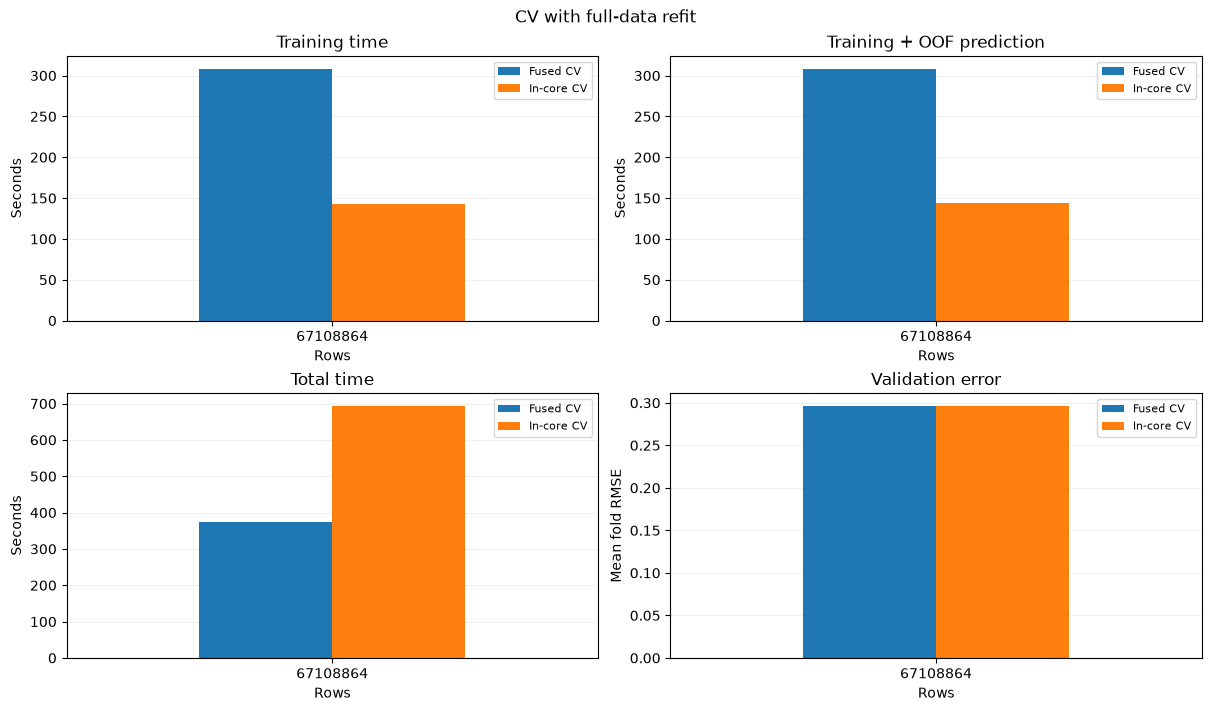

In [9]:
refit_fig, refit_axes = plt.subplots(2, 2, figsize=(12, 7), layout="constrained")
refit_fig.suptitle("CV with full-data refit")
for ax, column, title, ylabel in [
    (refit_axes[0, 0], "train_s", "Training time", "Seconds"),
    (refit_axes[0, 1], "fit_oof_s", "Training + OOF prediction", "Seconds"),
    (refit_axes[1, 0], "total_s", "Total time", "Seconds"),
    (refit_axes[1, 1], "mean_fold_rmse", "Validation error", "Mean fold RMSE"),
]:
    refit_summary[column].unstack("method").reindex(columns=METHODS).plot.bar(
        ax=ax, rot=0
    )
    ax.set(title=title, ylabel=ylabel)

for ax in refit_axes.flat:
    ax.set_xlabel("Rows")
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=8)
plt.show()